In [ ]:
import matplotlib.pyplot as plt
import asdf
import healpy as hp
import numpy as np
import pymaster as nmt
from tqdm import tqdm



In [28]:
z_array = np.linspace(0, 1.5, 200)
z_centers = 0.5 * (z_array[1:] + z_array[:-1])

nside = 2048

zvals = [0.3, 0.5, 0.725]

nz_gal_all = {}
Cl_gg_all = {}
nz_gal_all['z_array'] = z_centers

for jz, zval in enumerate(zvals):
    ldir = '/mnt/ceph/users/spandey/abacus'
    fn = f"{ldir}/z{zval:.3f}/catalog_DESI_LRG.asdf"
    f = asdf.open(fn)

    gal_ra, gal_dec = f['data']['RA'], f['data']['DEC']
    gal_z = f['data']['Z_COSMO']

    rand_ra, rand_dec = f['data']['RAND_RA'], f['data']['RAND_DEC']
    rand_z = f['data']['RAND_Z']

    hist_z = np.histogram(gal_z, bins=z_array, density=True)[0]
    hist_z_rand = np.histogram(rand_z, bins=z_array, density=True)[0]

    nz_gal_all[f'z{zval:.3f}'] = hist_z

    ipix = hp.ang2pix(nside, gal_ra, gal_dec, lonlat=True)
    npix = hp.nside2npix(nside)

    nmap = np.bincount(ipix, minlength=npix)

    ipix_rand = hp.ang2pix(nside, rand_ra, rand_dec, lonlat=True)
    npix_rand = hp.nside2npix(nside)

    nmap_rand = np.bincount(ipix_rand, minlength=npix_rand)

    lmax = 2*nside
    b = nmt.NmtBin.from_lmax_linear(lmax, nlb=100)
    leff = b.get_effective_ells()
    pos_data = np.array([f['data']['RA'], f['data']['DEC']])
    w_data = np.ones_like(f['data']['RA'])
    pos_ran = np.array([f['data']['RAND_RA'], f['data']['RAND_DEC']])
    w_ran = np.ones_like(f['data']['RAND_RA'])
    f_cat = nmt.NmtFieldCatalogClustering(pos_data, w_data, pos_ran, w_ran, lmax=lmax, lonlat=True)
    w_cat = nmt.NmtWorkspace.from_fields(f_cat, f_cat, b)
    pcl = nmt.compute_coupled_cell(f_cat, f_cat)
    cl_cat = w_cat.decouple_cell(pcl)

    Cl_gg_all['l_array'] = leff
    Cl_gg_all[f'z{zval:.3f}'] = cl_cat[0]



In [41]:
import pickle as pk
with open('/mnt/ceph/users/spandey/abacus/abacus_LRG_nz_Clgg.pkl', 'wb') as f:
    pk.dump({'nz_gal_all': nz_gal_all, 'Cl_gg_all': Cl_gg_all}, f)




Text(0, 0.5, '$C(\\ell)$')

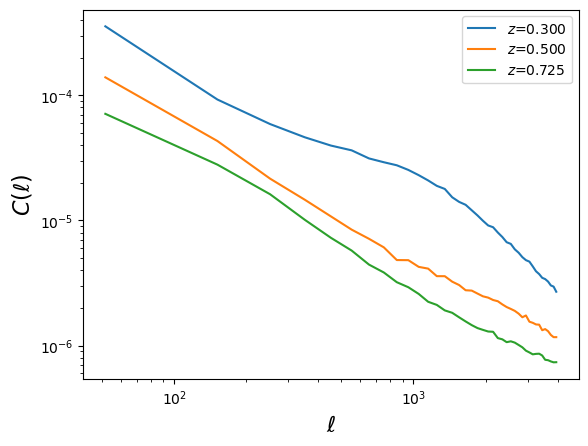

In [33]:
plt.figure()
for jz, zval in enumerate(zvals):
    plt.plot(Cl_gg_all['l_array'], Cl_gg_all[f'z{zval:.3f}'], label=fr'$z$={zval:.3f}')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel(r'$\ell$', fontsize=16)
plt.ylabel(r'$C(\ell)$', fontsize=16)


Text(0, 0.5, '$n(z)$')

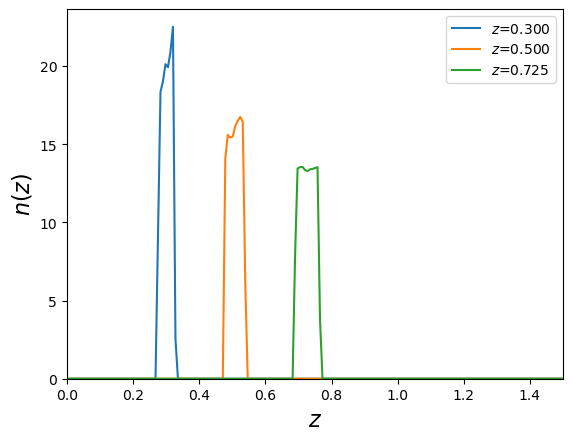

In [40]:
plt.figure()
for jz, zval in enumerate(zvals):
    plt.plot(nz_gal_all['z_array'], nz_gal_all[f'z{zval:.3f}'], label=fr'$z$={zval:.3f}')
# plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.ylim(0,)
plt.xlim(0, 1.5)
plt.xlabel(r'$z$', fontsize=16)
plt.ylabel(r'$n(z)$', fontsize=16)




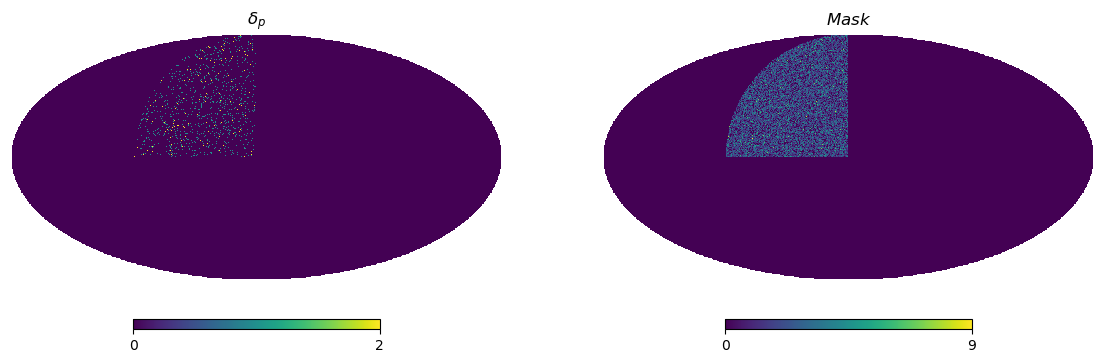

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10))
plt.axes(axes[0])
hp.mollview(nmap, title=r'$\delta_p$', hold=True, max=2)
plt.axes(axes[1])
hp.mollview(nmap_rand, title='$Mask$', hold=True)

